# **0. Описание ноутбука**

**Целью ноутбука** является выбрать среди базовых моделей наилучшую модель для дальнейшего его развития и использования

**Содержание:**
1. Подготовка датасета, библиотек, функций и переменных;
2. Обучение моделей;
3. Общей итог работы.

**Обучение и сравнение моделей:**
В ноутбуке присуствуют такие модели как:
```
Логистическая регрессия, SVM, Дерево значений, Случайный лес, Стекинг, CatBoost
```
Для каждой модели будут представлены 3 варианта данных для сравнения и подтверждения какая лучше на практике:

1.   Без BMI, но с Ростом и Весом
2.   С BMI, но без Роста и Веса
3.   Без BMI и без Роста и Веса

Для сравнение обратим внимание на такие метрики:
- F1-Score
- Log Loss
- Roc-auc
- Время обучения
- Precision
- Recall
- Accuracy


Важными метриками для нас являются:
- **F1-Score** из-за средних показателей Precision и Recall, а также из-за в отличие от Accuracy более надежен при дисбалансе классов;
- **Время обучения**, т.к. показывает скорость обучения;
- **Log Loss** для показа насколько можно довериться вроятностям модели;
- **ROC-AUC** для показа способности модели разделять классы.


# **1.1. Подготовка данных и инструментов**

*Описание импортов библиотек и готовых данных и инструментов*

## Загрузка и обработка данных

In [535]:
from pathlib import Path
import sys, os

REPO_DIR = 'Multiclass_prediction_of_obesity_risk'
REPO_URL = 'https://github.com/AlexTilta/Multiclass_prediction_of_obesity_risk.git'

if not os.path.isdir(REPO_DIR):
    print("Репозиторий не найден. Клонирование и установка зависимостей...")
    !git clone {REPO_URL}

    !pip -q install -r {REPO_DIR}/requirements.txt
else:
    print(f"Репозиторий '{REPO_DIR}' уже склонирован.")

%cd {REPO_DIR}

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


from src.utils import load_csv

df_original = load_csv('prepared_data.csv', 'data')
df_original.head()

Репозиторий не найден. Клонирование и установка зависимостей...
Cloning into 'Multiclass_prediction_of_obesity_risk'...
remote: Enumerating objects: 447, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 447 (delta 14), reused 11 (delta 11), pack-reused 411 (from 1)
Receiving objects: 100% (447/447), 18.07 MiB | 21.05 MiB/s, done.
Resolving deltas: 100% (196/196), done.
/content/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0000,1.6200,64.0000,yes,no,Sometimes,3,Sometimes,no,1-2,no,0,3-5,no,Public_Transportation,Normal_Weight,24.3865
1,Female,21.0000,1.5200,56.0000,yes,no,Always,3,Sometimes,yes,>2,yes,4-5,0-2,Sometimes,Public_Transportation,Normal_Weight,24.2382
2,Male,23.0000,1.8000,77.0000,yes,no,Sometimes,3,Sometimes,no,1-2,no,2-4,3-5,Frequently,Public_Transportation,Normal_Weight,23.7654
3,Male,27.0000,1.8000,87.0000,no,no,Always,3,Sometimes,no,1-2,no,2-4,0-2,Frequently,Walking,Overweight,26.8519
4,Male,22.0000,1.7800,89.8000,no,no,Sometimes,1-2,Sometimes,no,1-2,no,0,0-2,Sometimes,Public_Transportation,Overweight,28.3424


 ## Установка библиотек

In [536]:
!pip show catboost || pip install catboost
!pip show phik || pip install phik

Name: catboost
Version: 1.2.8
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
Name: phik
Version: 0.12.5
Summary: Phi_K correlation analyzer library
Home-page: 
Author: 
Author-email: "KPMG N.V. The Netherlands" <kave@kpmg.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, matplotlib, numpy, pandas, scipy
Required-by: 


## Библиотеки

In [576]:
# Общие библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, PolynomialFeatures
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, log_loss, roc_auc_score
)
# Библиотеки для отчетов
import json
import time
from IPython.display import display

# Утилиты
import joblib
import warnings
warnings.filterwarnings('ignore')
from phik import phik_matrix


# Библиотеки моделей или для конкретных моделей
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier
)
from catboost import CatBoostClassifier, Pool, cv

# **1.2. Настройка датасета**

*Описание констант для датасета(для быстрой настройки) и преобразования категориальных данных в числовые*

## Константы (для отчетов и редактирования наименований признаков)

In [538]:
# Целева переменная
TARGET_COLUMN = 'NObeyesdad'

# Константы для разных видов данных
ANTHROPOMETRICS = ['Height', 'Weight', 'BMI']

COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY = [TARGET_COLUMN, 'BMI']
COLUMNS_TO_DROP_BMI_ONLY = [TARGET_COLUMN, 'Height', 'Weight']
COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED = [TARGET_COLUMN] + ANTHROPOMETRICS

## Преобразование данных для большинство моделей

In [539]:
# Копирование данных (оригинал пригодится для CatBoost)
df_transformed = df_original.copy()

# Подготовка для преобразования строковых признаков
caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_transformed['CAEC'] = df_transformed['CAEC'].replace(caec_calc_map)
df_transformed['CALC'] = df_transformed['CALC'].replace(caec_calc_map)

fcvc_map = {'no': 0, 'Sometimes': 1, 'Always': 2}
df_transformed['FCVC'] = df_transformed['FCVC'].replace(fcvc_map)

ncp_map = {'1-2': 1.5, '3': 3.0, '>3': 3.5}
df_transformed['NCP'] = df_transformed['NCP'].replace(ncp_map)

ch2o_map = {'<1': 0.5, 'Sometimes': 1.0, '1-2': 1.5, '>2': 3.0}
df_transformed['CH2O'] = df_transformed['CH2O'].replace(ch2o_map)

faf_tue_map = {'0': 0, 'no': 0, '0-2': 1, '1-2': 1, '2-4': 3,
               '3-5': 4, '4-5': 4, '>5': 5}
df_transformed['FAF'] = df_transformed['FAF'].replace(faf_tue_map)
df_transformed['TUE'] = df_transformed['TUE'].replace(faf_tue_map)

yes_no_map = {'yes': 1.0, 'no': 0.0}
df_transformed['family_history_with_overweight'] = df_transformed['family_history_with_overweight'].replace(yes_no_map)
df_transformed['FAVC'] = df_transformed['FAVC'].replace(yes_no_map)
df_transformed['SMOKE'] = df_transformed['SMOKE'].replace(yes_no_map)
df_transformed['SCC'] = df_transformed['SCC'].replace(yes_no_map)

gender_map = {'Male': 1.0, 'Female': 0.0}
df_transformed['Gender'] = df_transformed['Gender'].replace(gender_map)

# Преобразование
mtrans_le = LabelEncoder()
df_transformed['MTRANS'] = mtrans_le.fit_transform(df_transformed['MTRANS']).astype(float)

df = df_transformed

INT_COLUMNS = ['FCVC', 'CAEC', 'FAF', 'TUE', 'CALC']
INT_COLUMNS_ADJUSTED = [col for col in INT_COLUMNS if col in df.columns]

for col in INT_COLUMNS_ADJUSTED:
    df[col] = df[col].astype('Int64')

EXCLUDE_COLUMNS = [TARGET_COLUMN] + INT_COLUMNS_ADJUSTED

COLUMNS_TO_FLOAT = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

for col in COLUMNS_TO_FLOAT:
    try:
        df[col] = df[col].astype(float)
    except Exception as e:
        pass

# Вывод
print(df.dtypes)
df

Gender                            float64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight    float64
FAVC                              float64
FCVC                                Int64
NCP                               float64
CAEC                                Int64
SMOKE                             float64
CH2O                              float64
SCC                               float64
FAF                                 Int64
TUE                                 Int64
CALC                                Int64
MTRANS                            float64
NObeyesdad                         object
BMI                               float64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0.0000,21.0000,1.6200,64.0000,1.0000,0.0000,1,3.0000,1,0.0000,1.5000,0.0000,0,4,0,3.0000,Normal_Weight,24.3865
1,0.0000,21.0000,1.5200,56.0000,1.0000,0.0000,2,3.0000,1,1.0000,3.0000,1.0000,4,1,1,3.0000,Normal_Weight,24.2382
2,1.0000,23.0000,1.8000,77.0000,1.0000,0.0000,1,3.0000,1,0.0000,1.5000,0.0000,3,4,2,3.0000,Normal_Weight,23.7654
3,1.0000,27.0000,1.8000,87.0000,0.0000,0.0000,2,3.0000,1,0.0000,1.5000,0.0000,3,1,2,4.0000,Overweight,26.8519
4,1.0000,22.0000,1.7800,89.8000,0.0000,0.0000,1,1.5000,1,0.0000,1.5000,0.0000,0,1,1,3.0000,Overweight,28.3424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0000,20.9768,1.7107,131.4085,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,3,4,1,3.0000,Obesity,44.9015
2083,0.0000,21.9829,1.7486,133.7429,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,1,4,1,3.0000,Obesity,43.7419
2084,0.0000,22.5240,1.7522,133.6894,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,1,4,1,3.0000,Obesity,43.5438
2085,0.0000,24.3619,1.7394,133.3466,1.0000,1.0000,2,3.0000,1,0.0000,3.0000,0.0000,1,4,1,3.0000,Obesity,44.0715


# **1.3. Переменные и функции для отчетности**

## Переменные для отчета

In [540]:
# Константы для названий моделей
MODEL_NAMES = {
    "log_reg": "Логистическая регрессия",
    "svm": "Модель SVM",
    "tree": "Деревья",
    "rf": "Случайный лес",
    "stacking": "Стекинг",
    "cat_boost": "CatBoost"
}

# Константы для названий метрик
METRIC_COLUMNS = {
    "F1": "F1-Score",
    "ACCURACY": "Accuracy",
    "PRECISION" : "Precision",
    "RECALL": "Recall)",
    "ROC_AUC": "ROC_AUC",
    "LogLoss": "LogLoss",
    "TIME": "Время CV (сек)"
}

# Сохранение результатов
result_hw = {}
result_bmi = {}
result_no_anthro = {}

## Функции для отчета

In [541]:
# Вывод таблицы
def display_formatted_table(comparison_results: dict):
    if not comparison_results:
        print("Словарь результатов пуст.")
        return

    df_results = pd.DataFrame.from_dict(comparison_results, orient='index')

    try:
        df_sorted = df_results.sort_values(
            by=METRIC_COLUMNS["F1"],
            ascending=False
        )
    except KeyError:
        print(f"Ошибка: В результатах отсутствует колонка для сортировки по F1-метрике ('{METRIC_COLUMNS['F1']}'). Сортировка пропущена.")
        df_sorted = df_results

    pd.options.display.float_format = '{:.4f}'.format

    try:
        if METRIC_COLUMNS["TIME"] in df_sorted.columns:
            df_sorted[METRIC_COLUMNS["TIME"]] = pd.to_numeric(df_sorted[METRIC_COLUMNS["TIME"]], errors='coerce')
            df_sorted[METRIC_COLUMNS["TIME"]] = df_sorted[METRIC_COLUMNS["TIME"]].apply(lambda x: f'{x:.2f}')
    except Exception as e:
        print(f"Ошибка при форматировании колонки времени '{METRIC_COLUMNS['TIME']}': {e}")

    display(df_sorted)

# **1.4. Общие объявления и функции для моделей**

*Общие переменные и функции для дальнейшего обучения*

## Объявления x, y, а также тренировочных и тестовых переменных

Для дальнейших возможностей запускать по отдельности каждый блок были объявлены три вариации значений.

### - Без BMI

In [542]:
# Для большинства моделей (df)
X_HW = df.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y = df[TARGET_COLUMN]
X_HW_train, X_HW_test, Y_HW_train, Y_HW_test = train_test_split(X_HW, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_HW_cat = df_original.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_HW_cat_train, X_HW_cat_test, Y_HW_cat_train, Y_HW_cat_test = train_test_split(X_HW_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - C BMI

In [543]:

# Для большинства моделей (df)
X_BMI = df.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y = df[TARGET_COLUMN]
X_BMI_train, X_BMI_test, Y_BMI_train, Y_BMI_test = train_test_split(X_BMI, Y, random_state=42, stratify=Y)


# Для CatBoost (df_original)
X_BMI_cat = df_original.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_BMI_cat_train, X_BMI_cat_test, Y_BMI_cat_train, Y_BMI_cat_test = train_test_split(X_BMI_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - Без BMI, без Роста и вес

In [544]:
# Для большинства моделей (df)
X_NO_ANTHRO = df.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y = df[TARGET_COLUMN]
X_NO_ANTHRO_train, X_NO_ANTHRO_test, Y_NO_ANTHRO_train, Y_NO_ANTHRO_test = train_test_split(X_NO_ANTHRO, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_NO_ANTHRO_cat = df_original.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y_cat = df_original[TARGET_COLUMN]
X_NO_ANTHRO_cat_train, X_NO_ANTHRO_cat_test, Y_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_test = train_test_split(X_NO_ANTHRO_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

## Функции для запуска моделей и вывода их результата

Также в этих функциях происходит получение отчетности данных точности и времени

**make_model** - для большинства моделей

In [545]:
def make_model(pipeline, x, y, model_name, results_dict):
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    class_names = [str(c) for c in sorted(y.unique())]

# Предсказание классов
    start_time = time.time()

    y_pred_cv_full = cross_val_predict(estimator=pipeline,
                                       X=x,
                                       y=y,
                                       cv=stratified_kfold,
                                       n_jobs=-1)

# Предсказание вероятностей (нужно для LogLoss и ROC_AUC)
    y_proba_cv_full = cross_val_predict(estimator=pipeline,
                                        X=x,
                                        y=y,
                                        cv=stratified_kfold,
                                        n_jobs=-1,
                                        method='predict_proba')

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    # Метрики
    report = classification_report(y, y_pred_cv_full, target_names=class_names, output_dict=True)

    weighted_f1_score = report['weighted avg']['f1-score']
    weighted_recall = report['weighted avg']['recall']
    weighted_precision = report['weighted avg']['precision']
    overall_accuracy = report['accuracy']

    logloss_score = log_loss(y, y_proba_cv_full)

    roc_auc_score_multiclass = roc_auc_score(
        y,
        y_proba_cv_full,
        multi_class='ovr',
        average='weighted'
    )

# Сохранение результатов
    results_dict[model_name] = {
          METRIC_COLUMNS["F1"]: weighted_f1_score,
          METRIC_COLUMNS["ACCURACY"]: overall_accuracy,
          METRIC_COLUMNS["LogLoss"]: logloss_score,
          METRIC_COLUMNS["RECALL"]: weighted_recall,
          METRIC_COLUMNS["PRECISION"]: weighted_precision,
          METRIC_COLUMNS["ROC_AUC"]: roc_auc_score_multiclass,
          METRIC_COLUMNS["TIME"]: cv_time_seconds
      }

# Выводы
    print("Classification Report - Full Model CV:")
    print(classification_report(y, y_pred_cv_full, target_names=class_names))
    print(f"\nLogLoss (Multiclass): {logloss_score:.4f}")
    print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")
    cm = confusion_matrix(y, y_pred_cv_full)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

**make_catboost_model** - только для catboost

**Заметка**:

Можно заметить, что в cv не будет строиться ни матрица ошибки и не будут находиться некоторые метрики. Причиной этому является либо невозможность получить эти значения с функции, либо незнание как можно получить эти метрики.

Для нас одни из главных метрик больше являются F1 и LogLoss, поэтому их значения получить удалось.

К тому же в дальнейшем CatBoost покажет хорошие результаты, но все же другим моделя он будет уступать, поэтому попытки как-то получить данные метрики с CatBoost было решено оставить как есть.

In [546]:
def make_catboost_model(model, x, y, cat_features, model_name, results_dict):
    start_time = time.time()

    params = model.get_params()

    params['custom_metric'] = ['TotalF1', 'Accuracy']

    # Обучение модели
    cv_data = cv(
        Pool(x, y, cat_features=cat_features),
        params,
        fold_count=5,
        seed=42,
        logging_level='Silent'
    )

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    # Метрики
    accuracy = cv_data['test-Accuracy-mean'].max()
    best_f1 = cv_data['test-TotalF1-mean'].max()

    logloss = cv_data['test-MultiClass-mean'].min()

    #  NaN для всех недоступных метрик
    precision = np.nan
    recall = np.nan
    roc_auc = np.nan

    results_dict[model_name] = {
        METRIC_COLUMNS["F1"]: best_f1,
        METRIC_COLUMNS["ACCURACY"]: accuracy,
        METRIC_COLUMNS["LogLoss"]: logloss,
        METRIC_COLUMNS["RECALL"]: recall,
        METRIC_COLUMNS["PRECISION"]: precision,
        METRIC_COLUMNS["ROC_AUC"]: roc_auc,
        METRIC_COLUMNS["TIME"]: cv_time_seconds
    }

    print(f"CatBoost CV завершен.")
    print(f"- F1: {best_f1:.4f}")
    print(f"- MultiClassLoss: {logloss:.4f}")
    print(f"- Accuracy: {accuracy:.4f}")
    print(f"- Время: {cv_time_seconds:.2f} секунд")

**display_final_model_evaluation** нужен для обучения на тестовых значениях

In [547]:
def display_final_model_evaluation(model, X_train, Y_train, X_test, Y_test, model_name):
    print(f"Запуск финального обучения модели {model_name}...")
    start_time = time.time()
    model.fit(X_train, Y_train)
    fit_time = time.time() - start_time
    print(f"\nФинальное обучение модели {model_name} заняло: {fit_time:.4f} секунд.")

    y_pred_test = model.predict(X_test)

    logloss_score = np.nan
    roc_auc_score_multiclass = np.nan

    try:
        y_proba_test = model.predict_proba(X_test)

        logloss_score = log_loss(Y_test, y_proba_test)

        roc_auc_score_multiclass = roc_auc_score(
            Y_test,
            y_proba_test,
            multi_class='ovr',
            average='weighted'
        )

    except AttributeError:
        print("\nВНИМАНИЕ: Модель не поддерживает predict_proba. LogLoss и ROC_AUC пропущены.")

    class_names = [str(c) for c in sorted(Y_test.unique())]

    print(f"\n--- Classification Report для {model_name} на Тесте ---")
    print(classification_report(Y_test, y_pred_test, target_names=class_names))

    if not np.isnan(logloss_score):
        print(f"LogLoss (Multiclass): {logloss_score:.4f}")
        print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")

    cm_test = confusion_matrix(Y_test, y_pred_test)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_test,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    print("-" * 50)
    print(f"Оценка модели {model_name} завершена.")

# **2.1. Общее описание  моделей**

В дальнейших пунктах 2.* будут продемонстрированы базовые модели с тремя вариациями данных. Итогами их будут выводы доступных значение, матриц и графиков.

В пункте 3 на таблицах сравнения будет сделан общий вывод для всех моделей

# **2.2. Логистическая регрессия**

In [548]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94       200
      Normal_Weight       0.90      0.71      0.79       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.90      0.96      0.93       424

           accuracy                           0.94      1565
          macro avg       0.92      0.91      0.91      1565
       weighted avg       0.94      0.94      0.94      1565


LogLoss (Multiclass): 0.2135
ROC_AUC (Weighted OVR): 0.9950


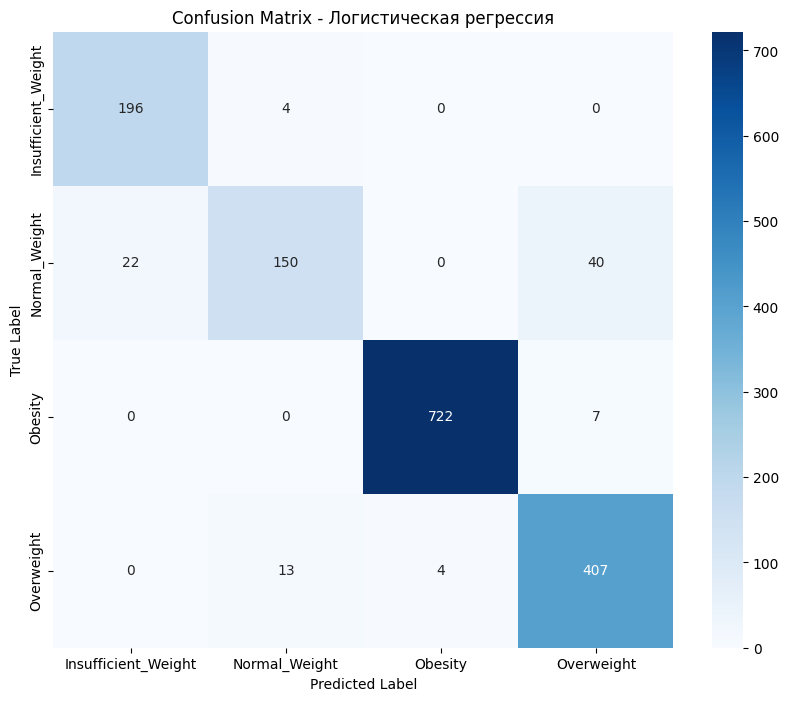

In [549]:
make_model(logreg_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["log_reg"], result_hw)

## C BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94       200
      Normal_Weight       0.94      0.76      0.84       212
            Obesity       1.00      0.99      0.99       729
         Overweight       0.92      0.98      0.95       424

           accuracy                           0.96      1565
          macro avg       0.94      0.93      0.93      1565
       weighted avg       0.96      0.96      0.96      1565


LogLoss (Multiclass): 0.1868
ROC_AUC (Weighted OVR): 0.9966


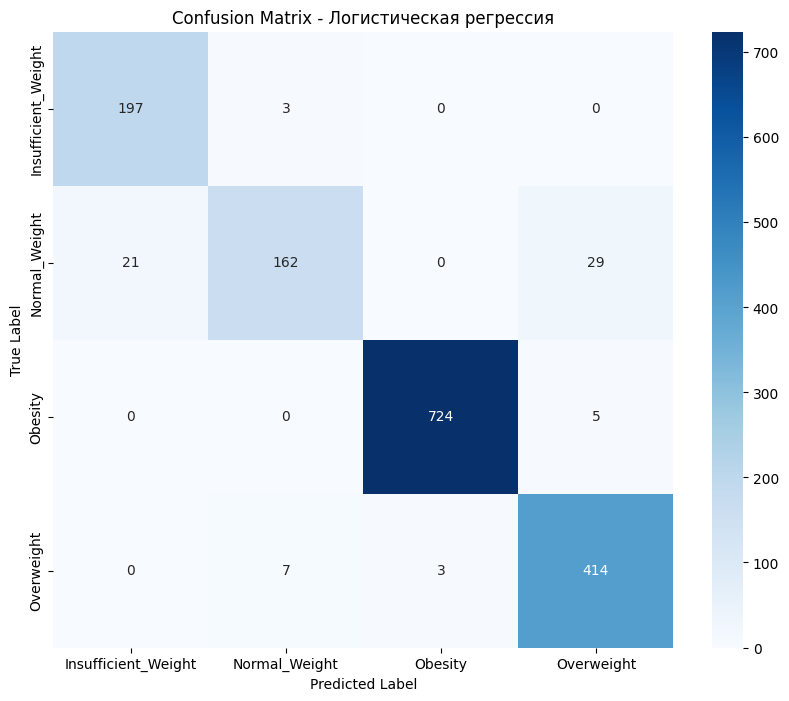

In [550]:
make_model(logreg_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["log_reg"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.53      0.49      0.51       200
      Normal_Weight       0.42      0.30      0.35       212
            Obesity       0.67      0.90      0.77       729
         Overweight       0.50      0.29      0.37       424

           accuracy                           0.60      1565
          macro avg       0.53      0.49      0.50      1565
       weighted avg       0.57      0.60      0.57      1565


LogLoss (Multiclass): 0.9021
ROC_AUC (Weighted OVR): 0.8075


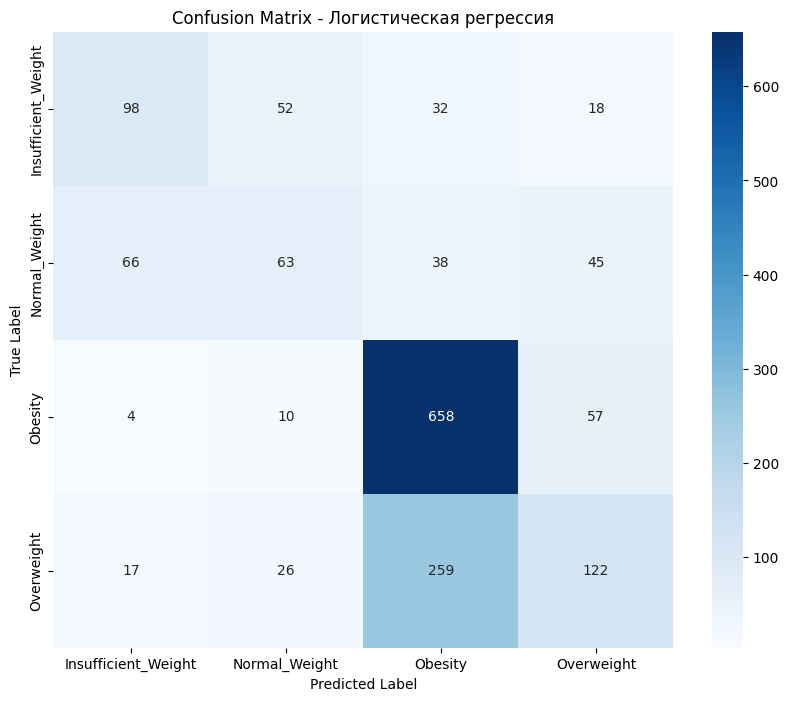

In [551]:
make_model(logreg_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["log_reg"], result_no_anthro)

# **2.3. SVM**

In [552]:
svm_pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', random_state=42, probability=True)
    )

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.99      0.95       200
      Normal_Weight       0.98      0.84      0.91       212
            Obesity       1.00      0.99      0.99       729
         Overweight       0.95      0.99      0.97       424

           accuracy                           0.97      1565
          macro avg       0.96      0.95      0.96      1565
       weighted avg       0.97      0.97      0.97      1565


LogLoss (Multiclass): 0.0783
ROC_AUC (Weighted OVR): 0.9988


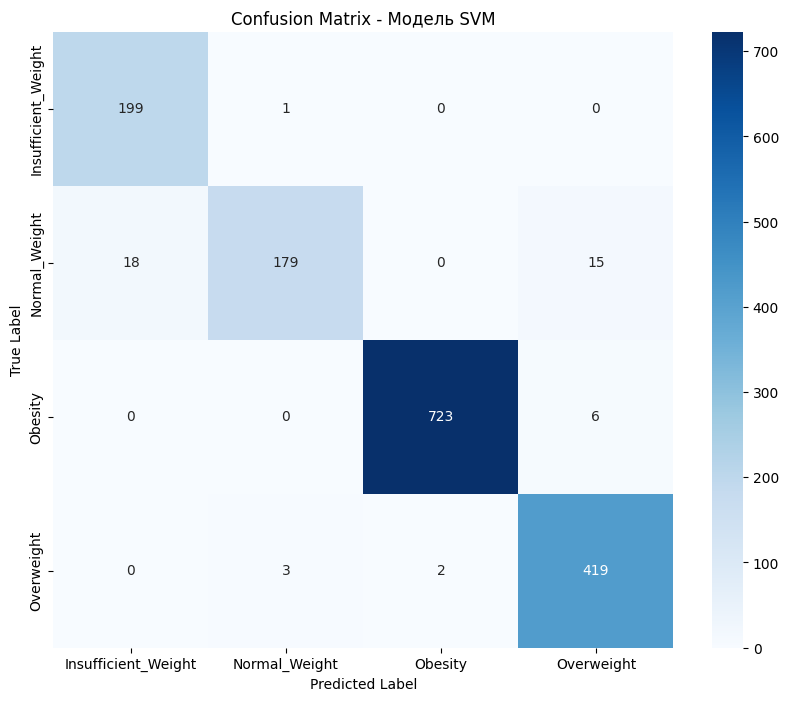

In [553]:
make_model(svm_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["svm"], result_hw)

## С BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.99      0.96       200
      Normal_Weight       0.97      0.87      0.92       212
            Obesity       1.00      0.99      1.00       729
         Overweight       0.97      0.98      0.97       424

           accuracy                           0.97      1565
          macro avg       0.96      0.96      0.96      1565
       weighted avg       0.97      0.97      0.97      1565


LogLoss (Multiclass): 0.0735
ROC_AUC (Weighted OVR): 0.9990


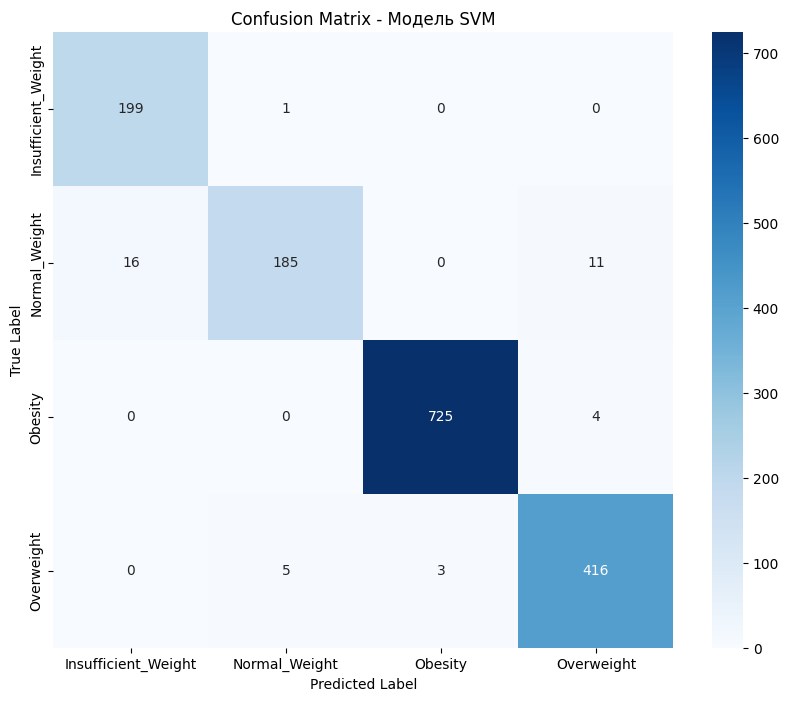

In [554]:
make_model(svm_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["svm"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.58      0.69      0.63       200
      Normal_Weight       0.45      0.31      0.36       212
            Obesity       0.68      0.96      0.79       729
         Overweight       0.64      0.22      0.33       424

           accuracy                           0.64      1565
          macro avg       0.58      0.54      0.53      1565
       weighted avg       0.62      0.64      0.59      1565


LogLoss (Multiclass): 0.8918
ROC_AUC (Weighted OVR): 0.7783


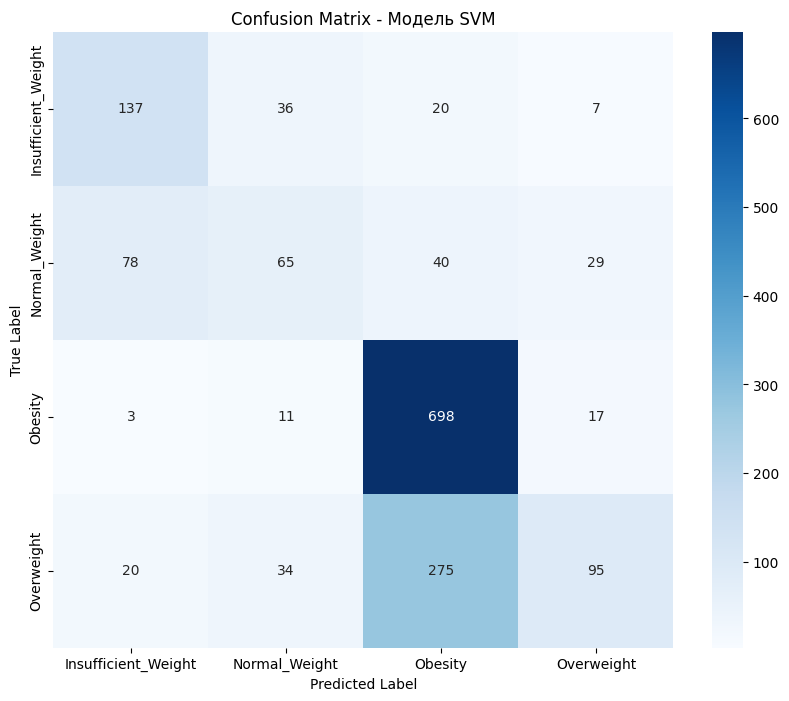

In [555]:
make_model(svm_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["svm"], result_no_anthro)

# **2.4. Дерево решений**

In [556]:
dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)


## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.98      0.95       200
      Normal_Weight       0.89      0.82      0.85       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.93      0.94      0.94       424

           accuracy                           0.95      1565
          macro avg       0.93      0.93      0.93      1565
       weighted avg       0.95      0.95      0.95      1565


LogLoss (Multiclass): 1.7504
ROC_AUC (Weighted OVR): 0.9685


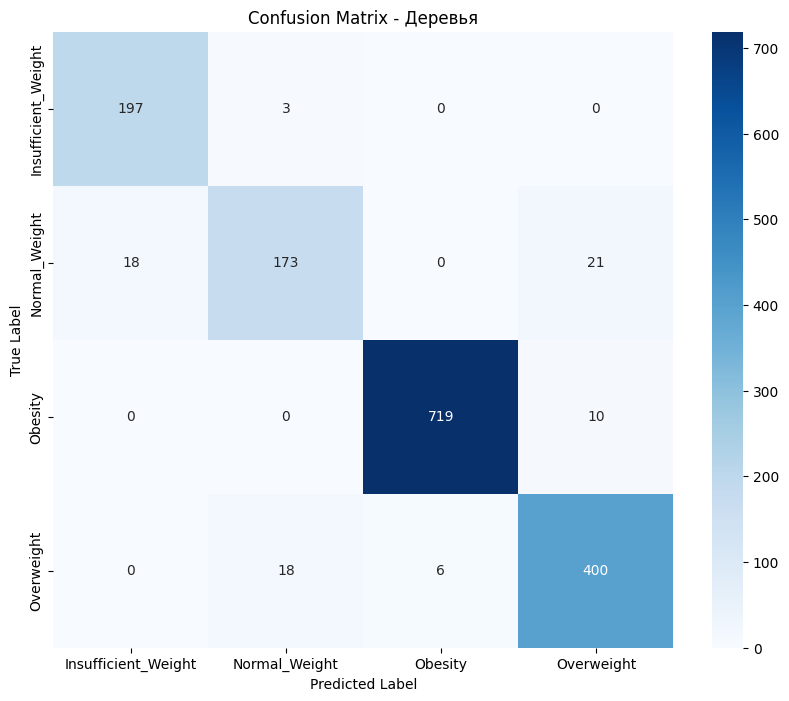

In [557]:
make_model(dt_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["tree"], result_hw)

## C BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.99      0.99       200
      Normal_Weight       0.97      0.94      0.95       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.98      0.98      0.98       424

           accuracy                           0.99      1565
          macro avg       0.98      0.98      0.98      1565
       weighted avg       0.99      0.99      0.99      1565


LogLoss (Multiclass): 0.5297
ROC_AUC (Weighted OVR): 0.9904


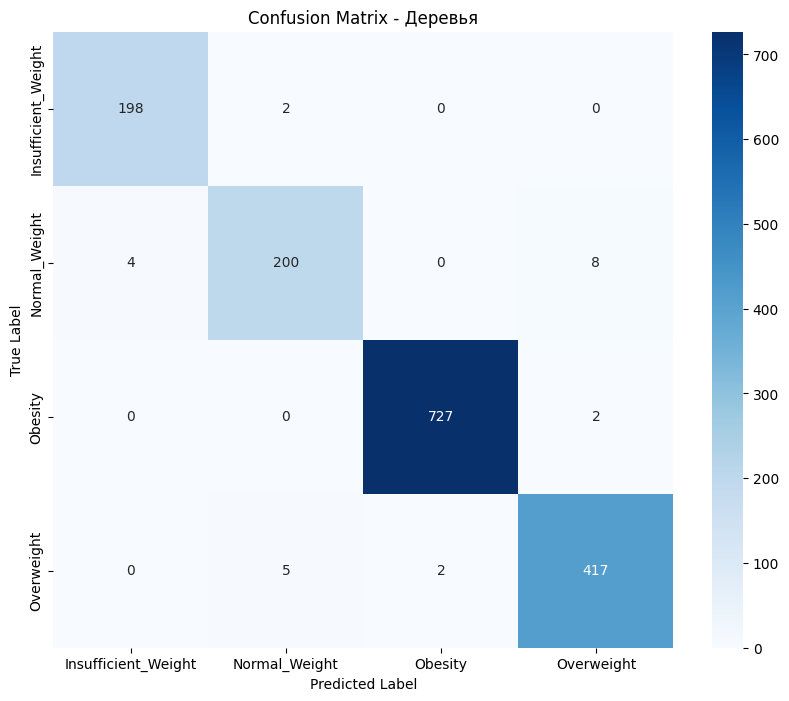

In [558]:
make_model(dt_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["tree"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.81      0.79       200
      Normal_Weight       0.53      0.52      0.53       212
            Obesity       0.86      0.85      0.86       729
         Overweight       0.69      0.69      0.69       424

           accuracy                           0.76      1565
          macro avg       0.71      0.72      0.72      1565
       weighted avg       0.76      0.76      0.76      1565


LogLoss (Multiclass): 8.5265
ROC_AUC (Weighted OVR): 0.8310


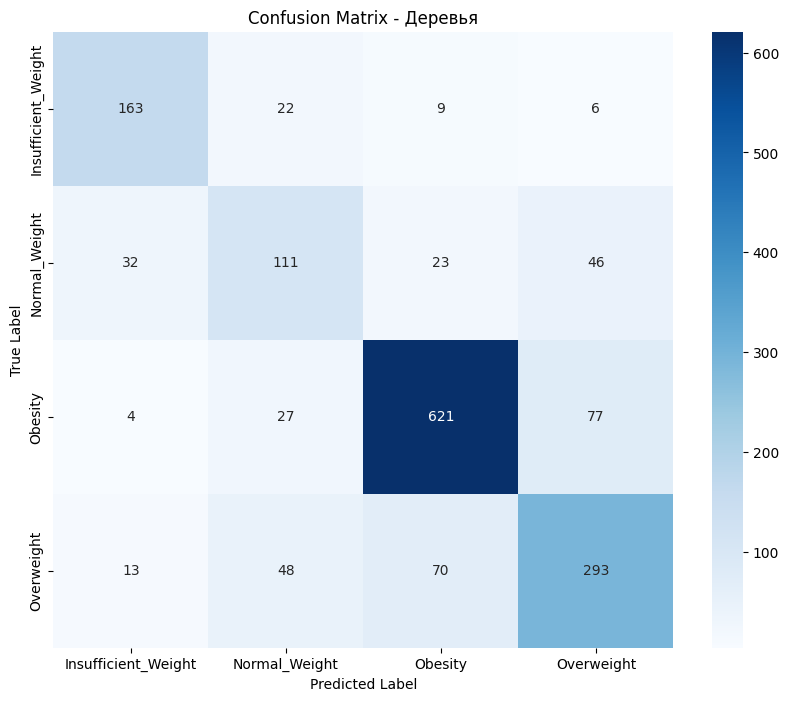

In [559]:
make_model(dt_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["tree"], result_no_anthro)

# **2.5. Бэггинг (Random Forest)**

In [560]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.94      0.94       200
      Normal_Weight       0.84      0.80      0.82       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.91      0.94      0.93       424

           accuracy                           0.95      1565
          macro avg       0.92      0.92      0.92      1565
       weighted avg       0.94      0.95      0.94      1565


LogLoss (Multiclass): 0.2330
ROC_AUC (Weighted OVR): 0.9954


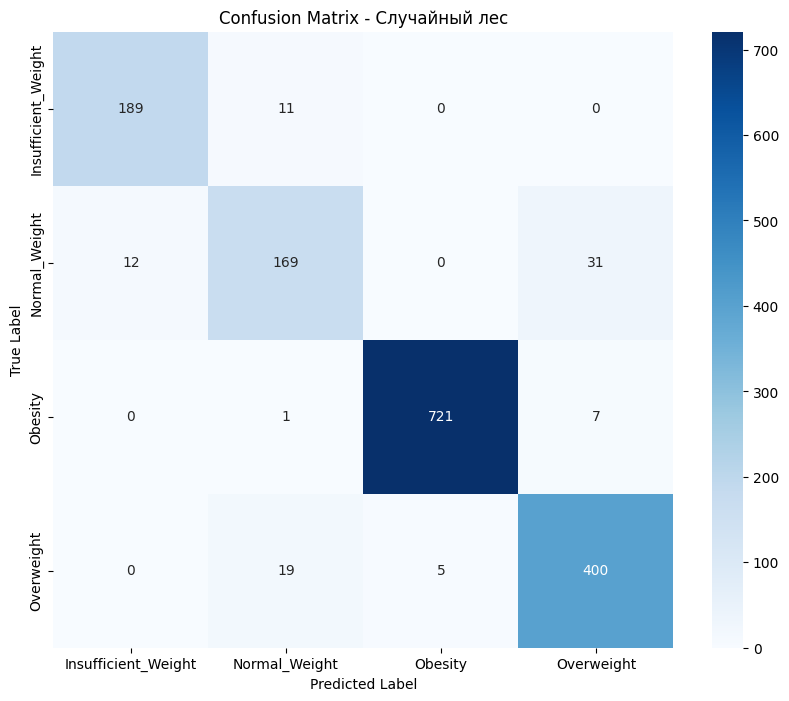

In [561]:
make_model(rf_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["rf"], result_hw)

## С BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98       200
      Normal_Weight       0.96      0.97      0.97       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.99      0.99      0.99       424

           accuracy                           0.99      1565
          macro avg       0.98      0.98      0.98      1565
       weighted avg       0.99      0.99      0.99      1565


LogLoss (Multiclass): 0.1537
ROC_AUC (Weighted OVR): 0.9997


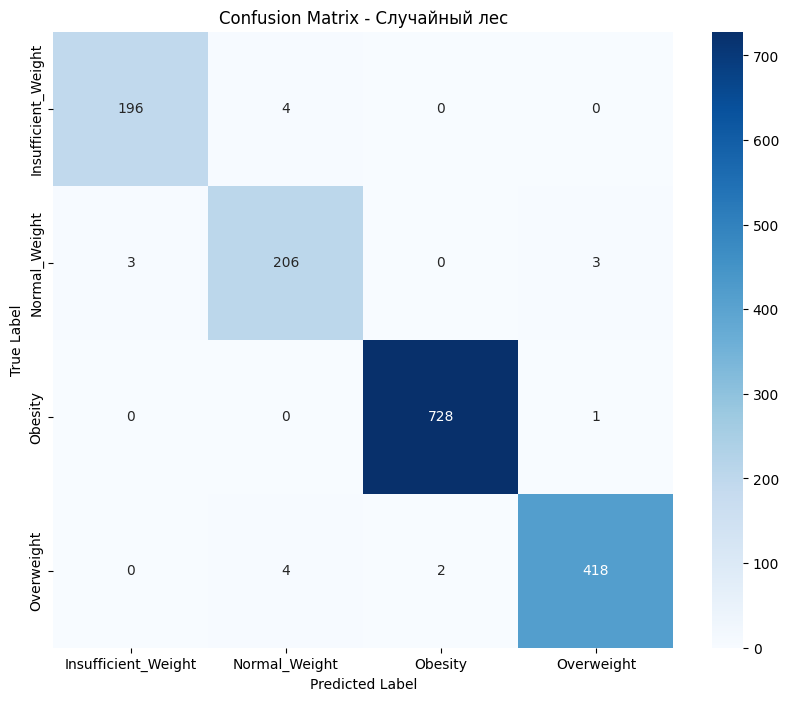

In [562]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.85      0.85       200
      Normal_Weight       0.65      0.54      0.59       212
            Obesity       0.80      0.95      0.87       729
         Overweight       0.77      0.60      0.67       424

           accuracy                           0.78      1565
          macro avg       0.77      0.73      0.74      1565
       weighted avg       0.78      0.78      0.78      1565


LogLoss (Multiclass): 0.5966
ROC_AUC (Weighted OVR): 0.9395


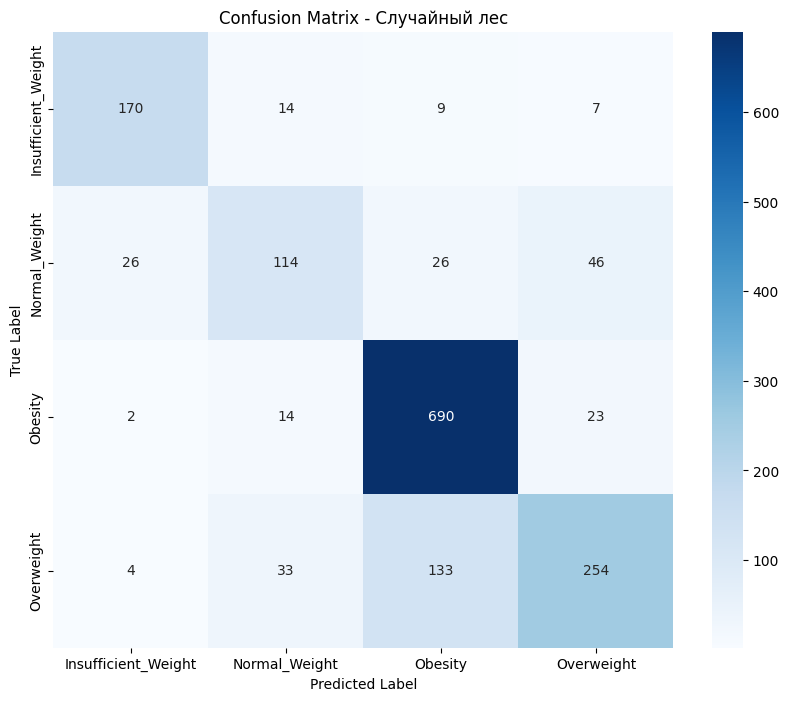

In [563]:
make_model(rf_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["rf"], result_no_anthro)

# **2.6. Стекинг**

In [564]:
estimators = [
    ('logreg', logreg_pipeline),
    ('svm', svm_pipeline),
    ('rf', rf_pipeline),
    ('dt', dt_pipeline)
]

final_estimator = LogisticRegression()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

stacking

StackingClassifier(cv=5,
                   estimators=[('logreg',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression(random_state=42))])),
                               ('svm',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(kernel='linear',
                                                     probability=True,
                                                     random_state=42))])),
                               ('rf',
                                Pipeline(steps=[('randomforestclassifier',
                                                 RandomForestClassifier(max_depth=10,
                                                                        n_jobs=-1,
                                                                        random_state=42))])),
                               ('dt',
                                Pipeline(steps=[('decisiontreeclassifier',
                                                 DecisionTreeClassifier(random_state=42))]))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.98      0.98       200
      Normal_Weight       0.95      0.93      0.94       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.98      0.98      0.98       424

           accuracy                           0.98      1565
          macro avg       0.97      0.97      0.97      1565
       weighted avg       0.98      0.98      0.98      1565


LogLoss (Multiclass): 0.0560
ROC_AUC (Weighted OVR): 0.9993


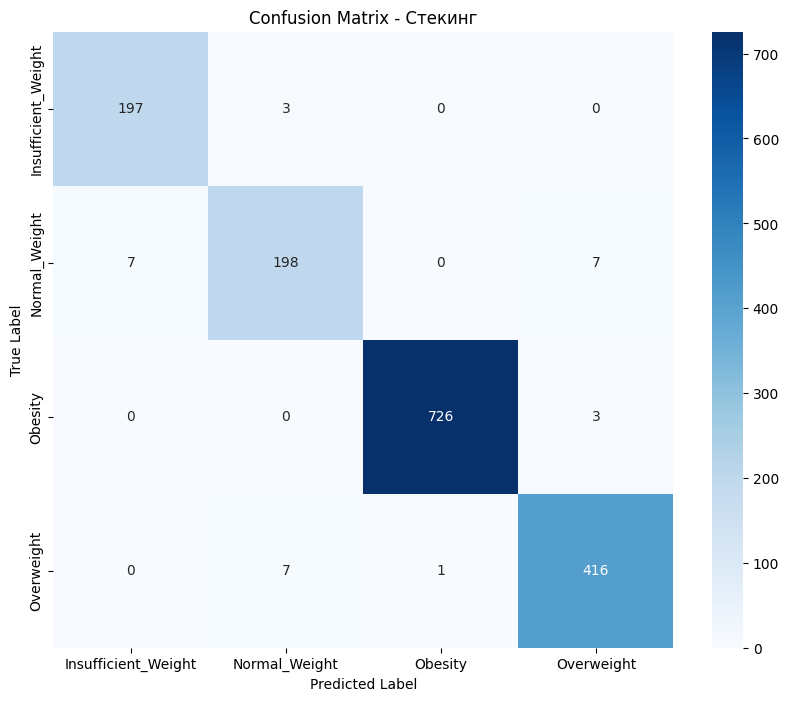

In [565]:
make_model(stacking, X_HW_train, Y_HW_train, MODEL_NAMES["stacking"], result_hw)

## C BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.99      0.99      0.99       200
      Normal_Weight       0.98      0.98      0.98       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.99      0.99      0.99       424

           accuracy                           0.99      1565
          macro avg       0.99      0.99      0.99      1565
       weighted avg       0.99      0.99      0.99      1565


LogLoss (Multiclass): 0.0330
ROC_AUC (Weighted OVR): 0.9998


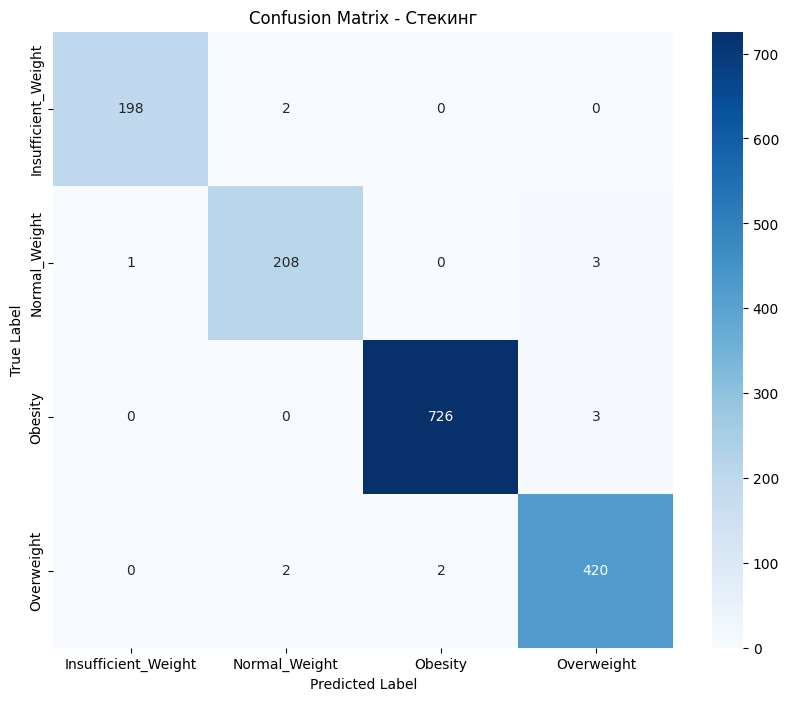

In [566]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.84      0.84       200
      Normal_Weight       0.67      0.57      0.62       212
            Obesity       0.87      0.91      0.89       729
         Overweight       0.75      0.75      0.75       424

           accuracy                           0.81      1565
          macro avg       0.78      0.77      0.77      1565
       weighted avg       0.81      0.81      0.81      1565


LogLoss (Multiclass): 0.5177
ROC_AUC (Weighted OVR): 0.9453


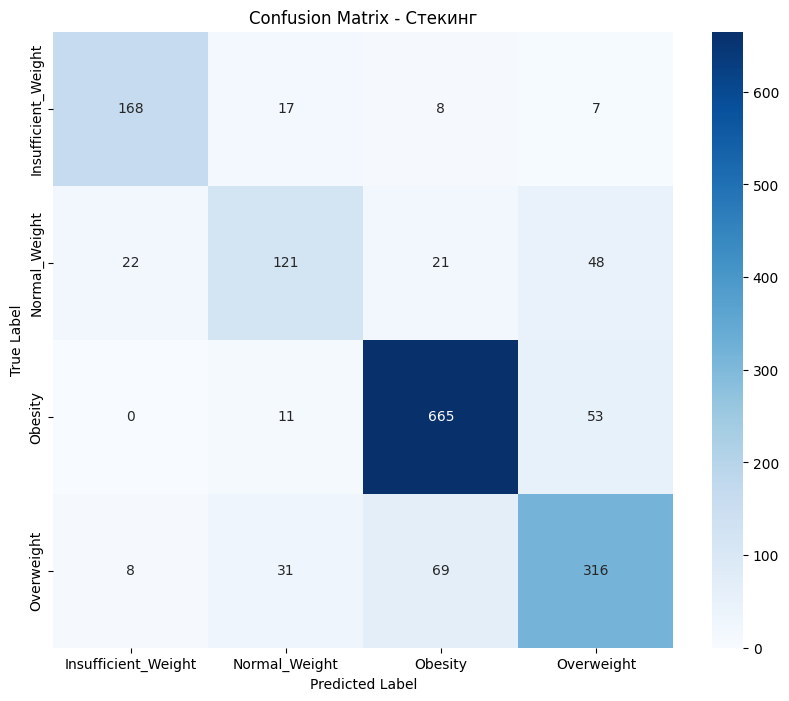

In [567]:
make_model(stacking, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["stacking"], result_no_anthro)

# **2.7. Бустинг (CatBoost)**

In [568]:
cbreg = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

In [569]:
make_catboost_model(cbreg, X_HW_cat_train, Y_HW_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_hw)

CatBoost CV завершен.
- F1: 0.9695
- MultiClassLoss: 0.1185
- Accuracy: 0.9699
- Время: 115.37 секунд


In [570]:
make_catboost_model(cbreg, X_BMI_cat_train, Y_BMI_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_bmi)

CatBoost CV завершен.
- F1: 0.9885
- MultiClassLoss: 0.0330
- Accuracy: 0.9885
- Время: 101.59 секунд


## Без BMI и без Роста и Веса

In [571]:
make_catboost_model(cbreg, X_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_no_anthro)

CatBoost CV завершен.
- F1: 0.7335
- MultiClassLoss: 0.6589
- Accuracy: 0.7431
- Время: 79.50 секунд


# **3.1. Таблицы сравнений**

Итак, выведем полученные значения из наших моделей:

In [572]:
print("\n### 1.  Результаты без показателя BMI (Рост/Вес включены)")
display_formatted_table(result_hw)
print("\n### 2.  Результаты c показателем BMI (Рост/Вес включены)")
display_formatted_table(result_bmi)
print("\n### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)")
display_formatted_table(result_no_anthro)


### 1.  Результаты без показателя BMI (Рост/Вес включены)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Стекинг,0.9821,0.9821,0.0560,0.9821,0.9821,0.9993,37.61
Модель SVM,0.9708,0.9712,0.0783,0.9712,0.9722,0.9988,2.81
CatBoost,0.9695,0.9699,0.1185,NaN,NaN,NaN,115.37
Деревья,0.9510,0.9514,1.7504,0.9514,0.9513,0.9685,0.37
Случайный лес,0.9447,0.9450,0.2330,0.9450,0.9447,0.9954,3.50
Логистическая регрессия,0.9405,0.9425,0.2135,0.9425,0.9427,0.9950,7.53



### 2.  Результаты c показателем BMI (Рост/Вес включены)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Стекинг,0.9917,0.9917,0.0330,0.9917,0.9917,0.9998,32.33
Случайный лес,0.9891,0.9891,0.1537,0.9891,0.9892,0.9997,5.72
CatBoost,0.9885,0.9885,0.0330,NaN,NaN,NaN,101.59
Деревья,0.9853,0.9853,0.5297,0.9853,0.9853,0.9904,0.23
Модель SVM,0.9741,0.9744,0.0735,0.9744,0.9749,0.9990,2.23
Логистическая регрессия,0.9553,0.9565,0.1868,0.9565,0.9573,0.9966,0.65



### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Стекинг,0.8087,0.8115,0.5177,0.8115,0.8074,0.9453,45.37
Случайный лес,0.7755,0.7847,0.5966,0.7847,0.7789,0.9395,4.06
Деревья,0.7588,0.7591,8.5265,0.7591,0.7588,0.8310,0.18
CatBoost,0.7335,0.7431,0.6589,NaN,NaN,NaN,79.50
Модель SVM,0.5882,0.6358,0.8918,0.6358,0.6225,0.7783,6.21
Логистическая регрессия,0.5686,0.6013,0.9021,0.6013,0.5713,0.8075,0.56


## **Какие же данные лучше всего использовать в дальнейшем?**
Сравнивая таблицы сравнений между собой можно сделать вывод, что **Данные С BMI** улучшают модель, чем без нее, а без признаков о весе и росте вычисления становятся в разы хуже



In [573]:
print("Результаты c показателем BMI (Рост/Вес включены)")
display_formatted_table(result_bmi)

Результаты c показателем BMI (Рост/Вес включены)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Стекинг,0.9917,0.9917,0.0330,0.9917,0.9917,0.9998,32.33
Случайный лес,0.9891,0.9891,0.1537,0.9891,0.9892,0.9997,5.72
CatBoost,0.9885,0.9885,0.0330,NaN,NaN,NaN,101.59
Деревья,0.9853,0.9853,0.5297,0.9853,0.9853,0.9904,0.23
Модель SVM,0.9741,0.9744,0.0735,0.9744,0.9749,0.9990,2.23
Логистическая регрессия,0.9553,0.9565,0.1868,0.9565,0.9573,0.9966,0.65


## **Какую модель мы выберем для дальнейшего развития?**
Даже среди трех разных данных, то лучший результат по точности показал **Стекинг**, находясь всегда на первом месте.

Однако, так как мы выбрали одни данные на которых далее будем развивать нашу модель, то кандитатом на выбор модели является **Случайный лес** за счет его скорости и не сильного отстования по точности.

# **3.2 Сравнения двух лучших моделей**

Для выбранных моделей выведем кросс-валидацию, обучение на тестовой выборки

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.99      0.99      0.99       200
      Normal_Weight       0.98      0.98      0.98       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.99      0.99      0.99       424

           accuracy                           0.99      1565
          macro avg       0.99      0.99      0.99      1565
       weighted avg       0.99      0.99      0.99      1565


LogLoss (Multiclass): 0.0330
ROC_AUC (Weighted OVR): 0.9998


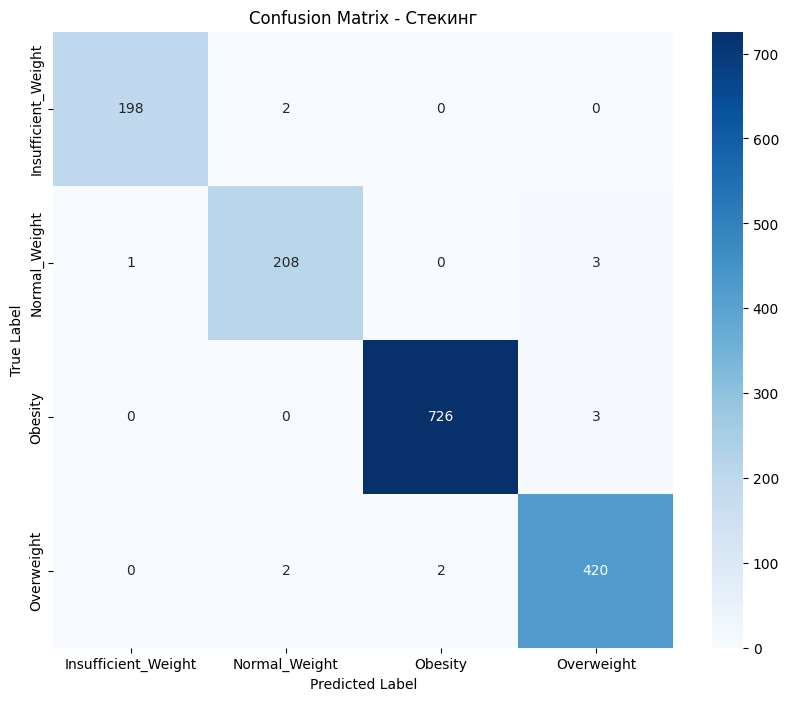

Запуск финального обучения модели Стекинг...

Финальное обучение модели Стекинг заняло: 2.9743 секунд.

--- Classification Report для Стекинг на Тесте ---
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.99      0.99        67
      Normal_Weight       0.97      0.99      0.98        70
            Obesity       0.99      1.00      1.00       243
         Overweight       0.99      0.98      0.99       142

           accuracy                           0.99       522
          macro avg       0.99      0.99      0.99       522
       weighted avg       0.99      0.99      0.99       522

LogLoss (Multiclass): 0.0354
ROC_AUC (Weighted OVR): 0.9998


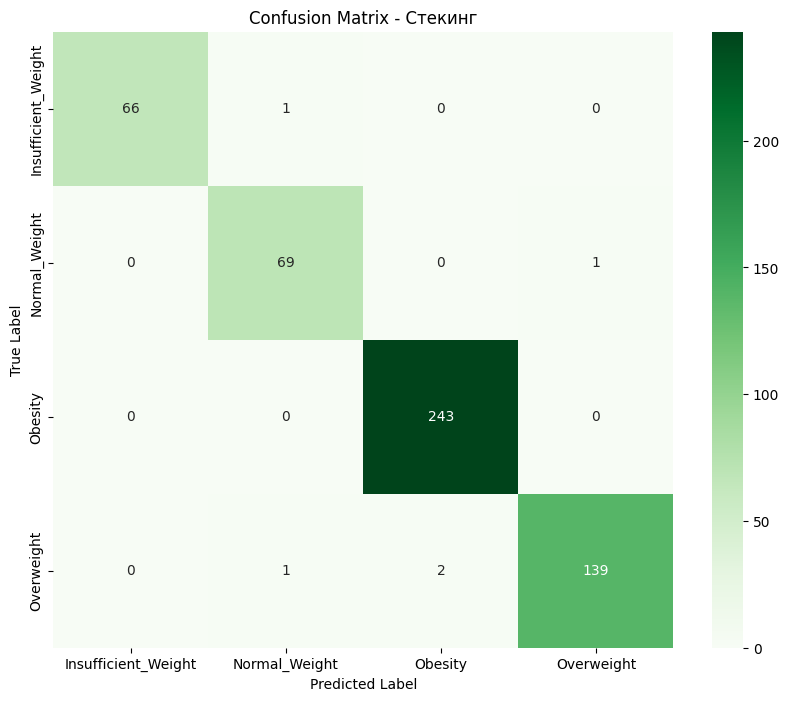

--------------------------------------------------
Оценка модели Стекинг завершена.


In [574]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi)

display_final_model_evaluation(stacking, X_BMI_train, Y_BMI_train, X_BMI_test, Y_BMI_test, MODEL_NAMES["stacking"])

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98       200
      Normal_Weight       0.96      0.97      0.97       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.99      0.99      0.99       424

           accuracy                           0.99      1565
          macro avg       0.98      0.98      0.98      1565
       weighted avg       0.99      0.99      0.99      1565


LogLoss (Multiclass): 0.1537
ROC_AUC (Weighted OVR): 0.9997


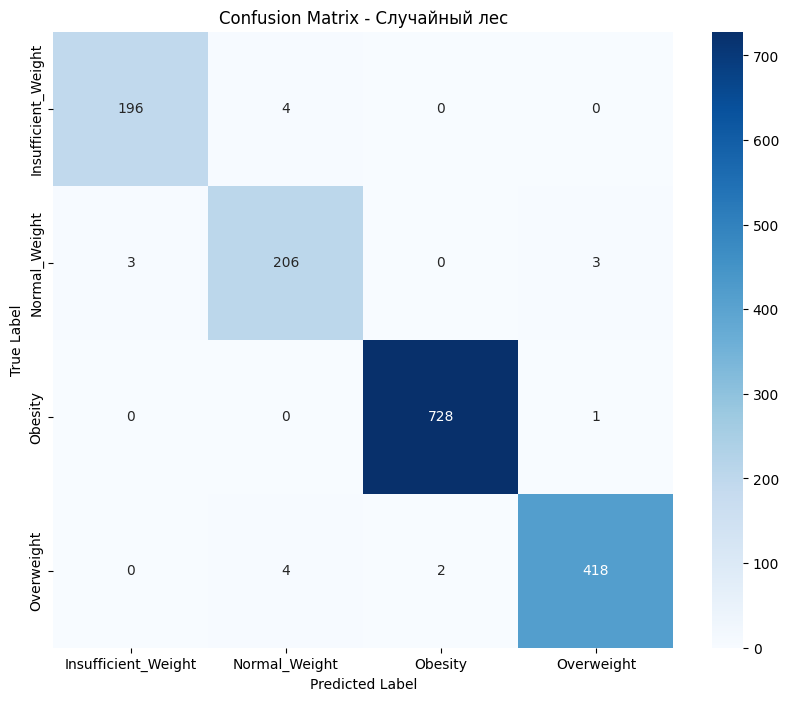

Запуск финального обучения модели Случайный лес...

Финальное обучение модели Случайный лес заняло: 0.6096 секунд.

--- Classification Report для Случайный лес на Тесте ---
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        67
      Normal_Weight       0.93      0.99      0.96        70
            Obesity       0.99      1.00      0.99       243
         Overweight       0.99      0.98      0.99       142

           accuracy                           0.98       522
          macro avg       0.98      0.98      0.98       522
       weighted avg       0.99      0.98      0.98       522

LogLoss (Multiclass): 0.1519
ROC_AUC (Weighted OVR): 0.9997


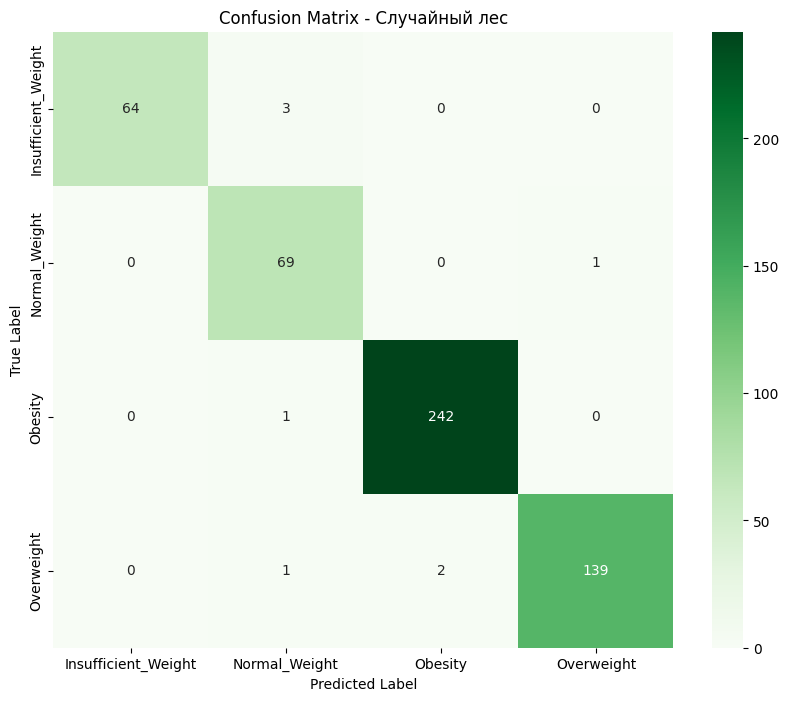

--------------------------------------------------
Оценка модели Случайный лес завершена.


In [575]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi)

display_final_model_evaluation(rf_pipeline, X_BMI_train, Y_BMI_train, X_BMI_test, Y_BMI_test, MODEL_NAMES["rf"])

Так как значения у двух моделей совпадают, то можно предположить, что переобучение отсуствует

# **3.3 Выводы**

В данном ноутбуке были проведены обучение 6-и базовых моделей на кросс-валидации и их сравнения для получения модели, которую будем использовать в дальнейшим для ее улучшения. Кандитатами на данную роль являются **Случайный лес** и **Стекинг**.

Точно нельзя сказать, какая модель лучше: **Случайный лес** запускается быстрее, однако **Стекинг** выполняется более точным. Поэтому дальнейшую модель стоит выбирать в зависимости от ресурсов и целей, которых хотим добиться.